In [ ]:
from pathlib import Path
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
PLANT_VILLAGE_DIR = DATA_DIR / "PlantVillage"
PLANT_DOC_DIR = DATA_DIR / "PlantDoc"

MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("PlantVillage exists:", PLANT_VILLAGE_DIR.exists())
print("PlantDoc exists:", PLANT_DOC_DIR.exists())
print("Torch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


Project root: /Users/saderod/Desktop/ai-plant-disease-detection
PlantVillage exists: True
PlantDoc exists: True
Torch: 2.2.2
Device: cpu


In [8]:
from src.utils import set_seed
from src.dataset import load_plantvillage, make_loaders
from src.model import build_model, count_parameters, unfreeze_backbone, load_checkpoint
from src.train import train_model
from src.evaluate import run_full_evaluation, plot_training_curves

set_seed(42)

print("Project modules imported successfully.")

Project modules imported successfully.


In [9]:
train_dataset, val_dataset, test_dataset, info = load_plantvillage(
    PLANT_VILLAGE_DIR,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=42,
)

train_loader, val_loader, test_loader = make_loaders(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=32,
    num_workers=0,
)

print("Dataset loaded successfully.")
print("Split sizes:", info["split_sizes"])
print("Number of classes:", info["n_classes"])
print("First 5 class counts:")

for class_name, count in list(info["class_counts"].items())[:5]:
    print(class_name, ":", count)

Dataset loaded successfully.
Split sizes: {'train': 14446, 'val': 3096, 'test': 3096, 'total': 20638}
Number of classes: 15
First 5 class counts:
Pepper__bell___Bacterial_spot : 997
Pepper__bell___healthy : 1478
Potato___Early_blight : 1000
Potato___Late_blight : 1000
Potato___healthy : 152


In [10]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())
print("First 10 labels:", labels[:10].tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Min pixel value: -2.1179039478302
Max pixel value: 2.640000104904175
First 10 labels: [11, 6, 8, 12, 7, 9, 12, 8, 10, 14]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model(
    n_classes=info["n_classes"],
    freeze_backbone=True,
).to(device)

params = count_parameters(model)

print("Device:", device)
print("Model created successfully.")
print("Parameters:", params)


Device: cpu
Model created successfully.
Parameters: {'total': 11184207, 'trainable': 7695, 'frozen': 11176512}


In [12]:
with torch.no_grad():
    sample_outputs = model(images.to(device))

print("Sample output shape:", sample_outputs.shape)
print("Expected output shape: [32, 15]")

Sample output shape: torch.Size([32, 15])
Expected output shape: [32, 15]


In [13]:
phase1_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=1,
    learning_rate=0.001,
    class_weights=info["class_weights"],
    device=device,
    checkpoint_path=str(MODELS_DIR / "resnet18_phase1_best.pth"),
    history_path=str(RESULTS_DIR / "history_phase1.json"),
    phase_name="phase1_frozen_backbone",
)

print("Phase 1 training completed.")



Training phase1_frozen_backbone
Epochs: 1
Learning rate: 0.001
Trainable parameters: 7,695


Epoch 1/1 | Train Loss: 1.2816 | Train Acc: 0.6321 | Val Loss: 0.6490 | Val Acc: 0.8211 | Time: 1305s
Best checkpoint saved: 0.8211
Phase 1 training completed.


In [14]:
phase1_report = run_full_evaluation(
    model=model,
    test_loader=test_loader,
    class_names=info["class_names"],
    device=device,
    results_dir=RESULTS_DIR,
    figures_dir=FIGURES_DIR,
    label="phase1",
)

print("Phase 1 evaluation completed.")

predict: 100%|██████████| 97/97 [03:44<00:00,  2.32s/it]


Accuracy: 0.8217
Macro F1: 0.7914
Weighted F1: 0.8301
Phase 1 evaluation completed.


In [15]:
plot_training_curves(
    phase1_history,
    save_path=FIGURES_DIR / "training_curves_phase1.png",
)

print("Phase 1 training curves saved.")

Phase 1 training curves saved.


In [16]:
load_checkpoint(
    model,
    str(MODELS_DIR / "resnet18_phase1_best.pth"),
)

unfreeze_backbone(model)

params = count_parameters(model)

print("Best Phase 1 checkpoint loaded.")
print("Backbone unfrozen for Phase 2.")
print("Parameters:", params)

Best Phase 1 checkpoint loaded.
Backbone unfrozen for Phase 2.
Parameters: {'total': 11184207, 'trainable': 11184207, 'frozen': 0}


In [17]:
phase2_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=1,
    learning_rate=0.0001,
    class_weights=info["class_weights"],
    device=device,
    checkpoint_path=str(MODELS_DIR / "resnet18_phase2_best.pth"),
    history_path=str(RESULTS_DIR / "history_phase2.json"),
    phase_name="phase2_full_finetuning",
)

print("Phase 2 training completed.")



Training phase2_full_finetuning
Epochs: 1
Learning rate: 0.0001
Trainable parameters: 11,184,207


Epoch 1/1 | Train Loss: 0.2169 | Train Acc: 0.9320 | Val Loss: 0.0677 | Val Acc: 0.9767 | Time: 2972s
Best checkpoint saved: 0.9767
Phase 2 training completed.


In [18]:
phase2_report = run_full_evaluation(
    model=model,
    test_loader=test_loader,
    class_names=info["class_names"],
    device=device,
    results_dir=RESULTS_DIR,
    figures_dir=FIGURES_DIR,
    label="phase2",
)

print("Phase 2 evaluation completed.")

predict: 100%|██████████| 97/97 [03:15<00:00,  2.02s/it]


Accuracy: 0.9738
Macro F1: 0.9718
Weighted F1: 0.9737
Phase 2 evaluation completed.


In [19]:
phase2_report = run_full_evaluation(
    model=model,
    test_loader=test_loader,
    class_names=info["class_names"],
    device=device,
    results_dir=RESULTS_DIR,
    figures_dir=FIGURES_DIR,
    label="phase2",
)

print("Phase 2 evaluation completed.")


predict: 100%|██████████| 97/97 [03:11<00:00,  1.97s/it]


Accuracy: 0.9738
Macro F1: 0.9718
Weighted F1: 0.9737
Phase 2 evaluation completed.


In [20]:
plot_training_curves(
    phase2_history,
    save_path=FIGURES_DIR / "training_curves_phase2.png",
)

print("Phase 2 training curves saved.")

Phase 2 training curves saved.


In [21]:
comparison_data = {
    "Experiment": [
        "Phase 1 - Frozen Backbone",
        "Phase 2 - Full Fine-Tuning",
    ],
    "Best Validation Accuracy": [
        phase1_history["best_val_accuracy"],
        phase2_history["best_val_accuracy"],
    ],
    "Test Accuracy": [
        phase1_report["overall_accuracy"],
        phase2_report["overall_accuracy"],
    ],
    "Macro F1": [
        phase1_report["macro avg"]["f1-score"],
        phase2_report["macro avg"]["f1-score"],
    ],
    "Weighted F1": [
        phase1_report["weighted avg"]["f1-score"],
        phase2_report["weighted avg"]["f1-score"],
    ],
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df.to_csv(
    RESULTS_DIR / "phase1_phase2_comparison.csv",
    index=False,
)

comparison_df

,Experiment,Best Validation Accuracy,Test Accuracy,Macro F1,Weighted F1
0,Phase 1 - Frozen Backbone,0.821059,0.821705,0.791386,0.830073
1,Phase 2 - Full Fine-Tuning,0.976744,0.973837,0.971802,0.973721


In [22]:
report_comparison_df = comparison_df.copy()

numeric_columns = [
    "Best Validation Accuracy",
    "Test Accuracy",
    "Macro F1",
    "Weighted F1",
]

for column in numeric_columns:
    report_comparison_df[column] = report_comparison_df[column].round(4)

report_comparison_df.to_csv(
    RESULTS_DIR / "phase1_phase2_comparison_rounded.csv",
    index=False,
)

report_comparison_df

,Experiment,Best Validation Accuracy,Test Accuracy,Macro F1,Weighted F1
0,Phase 1 - Frozen Backbone,0.8211,0.8217,0.7914,0.8301
1,Phase 2 - Full Fine-Tuning,0.9767,0.9738,0.9718,0.9737


In [23]:
expected_files = [
    MODELS_DIR / "resnet18_phase1_best.pth",
    MODELS_DIR / "resnet18_phase2_best.pth",
    RESULTS_DIR / "history_phase1.json",
    RESULTS_DIR / "history_phase2.json",
    RESULTS_DIR / "classification_report_phase1.csv",
    RESULTS_DIR / "classification_report_phase2.csv",
    RESULTS_DIR / "phase1_phase2_comparison.csv",
    RESULTS_DIR / "phase1_phase2_comparison_rounded.csv",
    FIGURES_DIR / "training_curves_phase1.png",
    FIGURES_DIR / "training_curves_phase2.png",
    FIGURES_DIR / "confusion_matrix_phase1.png",
    FIGURES_DIR / "confusion_matrix_phase2.png",
    FIGURES_DIR / "per_class_f1_phase1.png",
    FIGURES_DIR / "per_class_f1_phase2.png",
]

for file_path in expected_files:
    print(file_path.name, "→", file_path.exists())

resnet18_phase1_best.pth → True
resnet18_phase2_best.pth → True
history_phase1.json → True
history_phase2.json → True
classification_report_phase1.csv → True
classification_report_phase2.csv → True
phase1_phase2_comparison.csv → True
phase1_phase2_comparison_rounded.csv → True
training_curves_phase1.png → True
training_curves_phase2.png → True
confusion_matrix_phase1.png → True
confusion_matrix_phase2.png → True
per_class_f1_phase1.png → True
per_class_f1_phase2.png → True


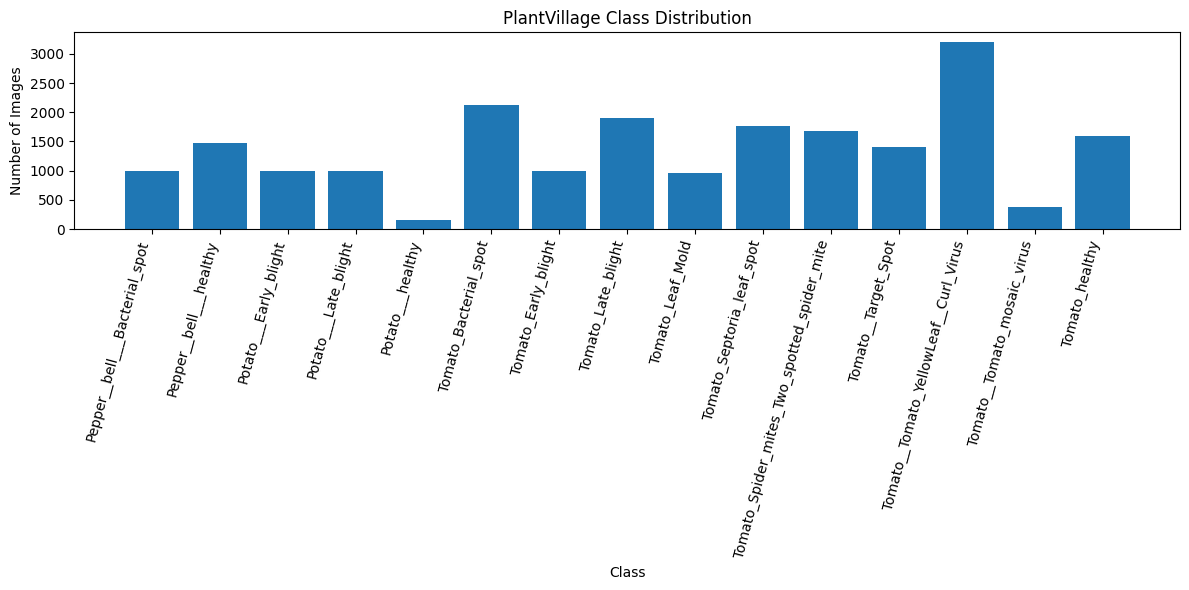

,Class,Image Count
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,Potato___Early_blight,1000
3,Potato___Late_blight,1000
4,Potato___healthy,152
5,Tomato_Bacterial_spot,2127
6,Tomato_Early_blight,1000
7,Tomato_Late_blight,1909
8,Tomato_Leaf_Mold,952
9,Tomato_Septoria_leaf_spot,1771


In [24]:
class_distribution_df = pd.DataFrame({
    "Class": list(info["class_counts"].keys()),
    "Image Count": list(info["class_counts"].values()),
})

class_distribution_df.to_csv(
    RESULTS_DIR / "class_distribution.csv",
    index=False,
)

plt.figure(figsize=(12, 6))
plt.bar(class_distribution_df["Class"], class_distribution_df["Image Count"])
plt.xticks(rotation=75, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("PlantVillage Class Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=300)
plt.show()

class_distribution_df

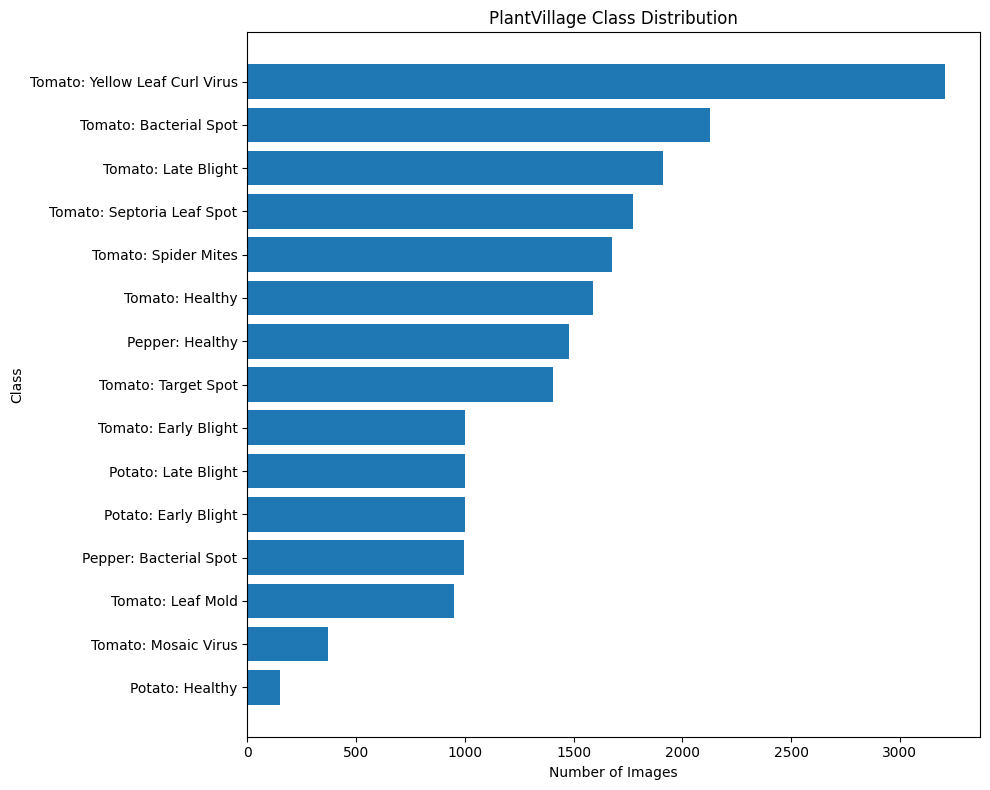

Largest class count: 3208
Smallest class count: 152
Imbalance ratio: 21.11


,Class,Image Count
4,Potato: Healthy,152
13,Tomato: Mosaic Virus,373
8,Tomato: Leaf Mold,952
0,Pepper: Bacterial Spot,997
2,Potato: Early Blight,1000
3,Potato: Late Blight,1000
6,Tomato: Early Blight,1000
11,Tomato: Target Spot,1404
1,Pepper: Healthy,1478
14,Tomato: Healthy,1591


In [25]:
from src.utils import DISPLAY_NAMES

class_distribution_clean_df = pd.DataFrame({
    "Class": DISPLAY_NAMES,
    "Image Count": list(info["class_counts"].values()),
})

class_distribution_clean_df = class_distribution_clean_df.sort_values(
    by="Image Count",
    ascending=True,
)

class_distribution_clean_df.to_csv(
    RESULTS_DIR / "class_distribution_clean.csv",
    index=False,
)

plt.figure(figsize=(10, 8))
plt.barh(
    class_distribution_clean_df["Class"],
    class_distribution_clean_df["Image Count"],
)
plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("PlantVillage Class Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution_clean.png", dpi=300)
plt.show()

max_count = class_distribution_clean_df["Image Count"].max()
min_count = class_distribution_clean_df["Image Count"].min()
imbalance_ratio = max_count / min_count

print("Largest class count:", max_count)
print("Smallest class count:", min_count)
print("Imbalance ratio:", round(imbalance_ratio, 2))

class_distribution_clean_df

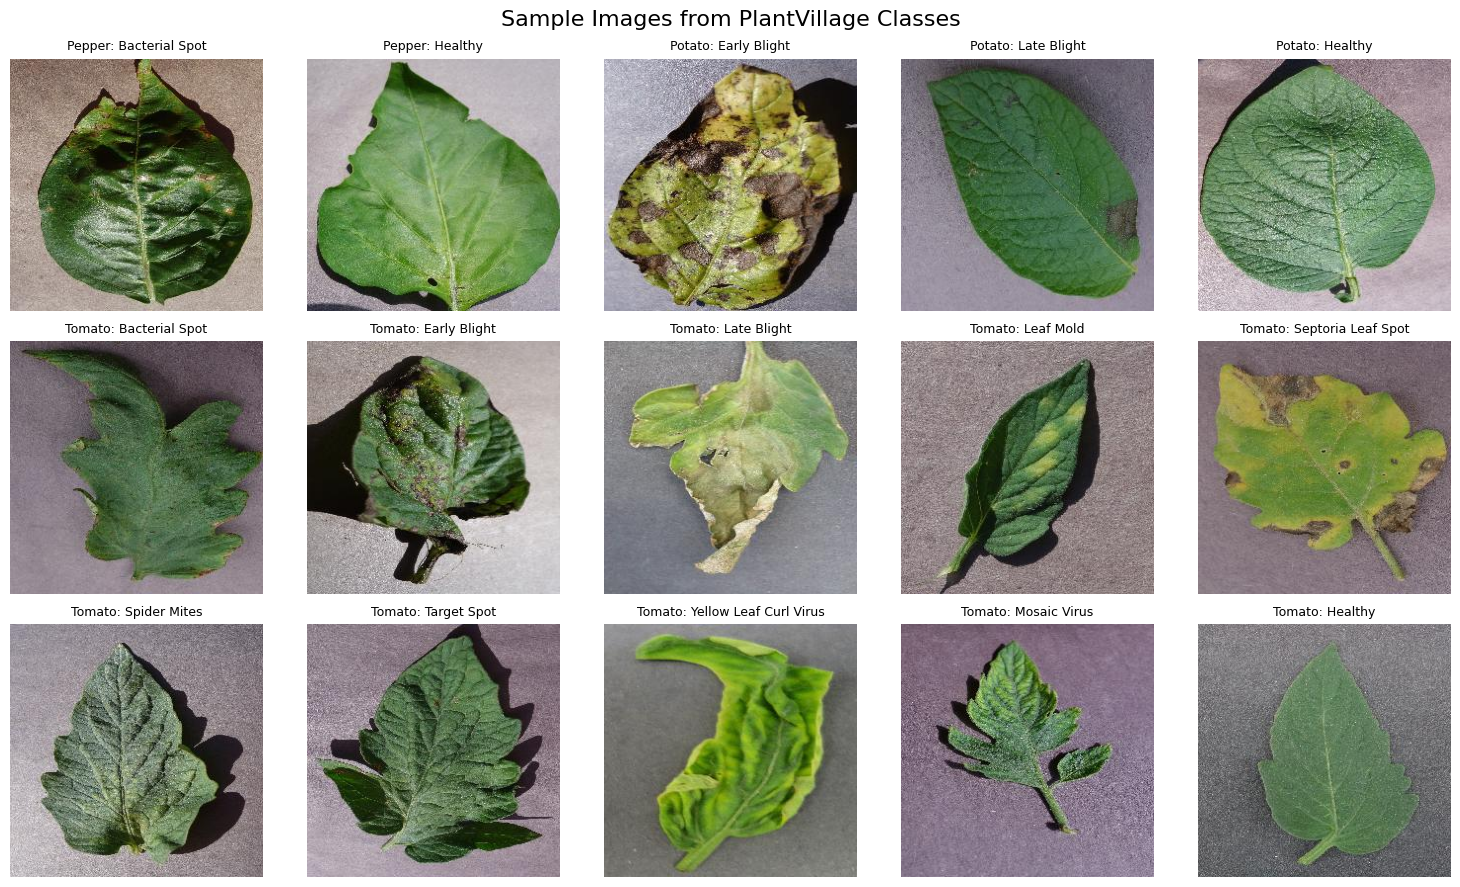

Sample image grid saved.


In [26]:
import random
from PIL import Image

sample_paths = []

for class_name in info["class_names"]:
    class_dir = PLANT_VILLAGE_DIR / class_name
    image_files = sorted([
        p for p in class_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])
    sample_paths.append(random.choice(image_files))

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for ax, image_path, display_name in zip(axes, sample_paths, DISPLAY_NAMES):
    image = Image.open(image_path).convert("RGB")
    ax.imshow(image)
    ax.set_title(display_name, fontsize=9)
    ax.axis("off")

plt.suptitle("Sample Images from PlantVillage Classes", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_images_clean.png", dpi=300)
plt.show()

print("Sample image grid saved.")

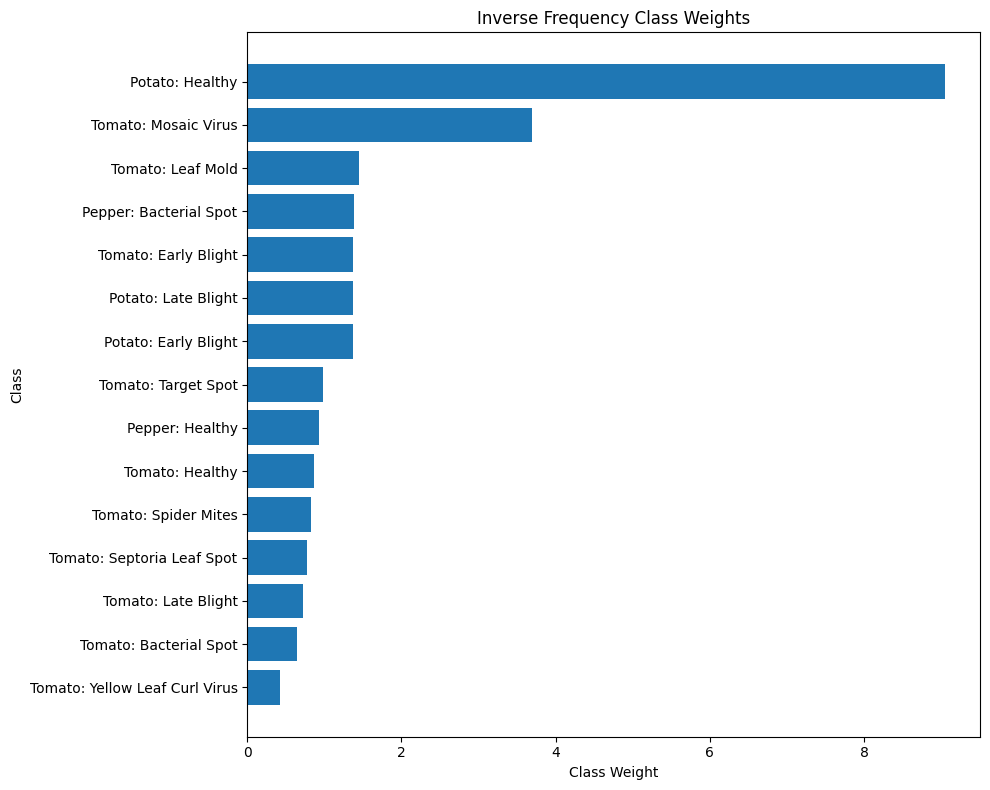

,Class,Class Weight
12,Tomato: Yellow Leaf Curl Virus,0.428886
5,Tomato: Bacterial Spot,0.646858
7,Tomato: Late Blight,0.720726
9,Tomato: Septoria Leaf Spot,0.776887
10,Tomato: Spider Mites,0.820923
14,Tomato: Healthy,0.864781
1,Pepper: Healthy,0.930898
11,Tomato: Target Spot,0.979962
2,Potato: Early Blight,1.375867
3,Potato: Late Blight,1.375867


In [27]:
class_weights_df = pd.DataFrame({
    "Class": DISPLAY_NAMES,
    "Class Weight": info["class_weights"].numpy(),
})

class_weights_df = class_weights_df.sort_values(
    by="Class Weight",
    ascending=True,
)

class_weights_df.to_csv(
    RESULTS_DIR / "class_weights.csv",
    index=False,
)

plt.figure(figsize=(10, 8))
plt.barh(
    class_weights_df["Class"],
    class_weights_df["Class Weight"],
)
plt.xlabel("Class Weight")
plt.ylabel("Class")
plt.title("Inverse Frequency Class Weights")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_weights.png", dpi=300)
plt.show()

class_weights_df

In [28]:
phase2_report_df = pd.DataFrame(phase2_report).transpose()

phase2_report_clean = phase2_report_df[
    ["precision", "recall", "f1-score", "support"]
].copy()

phase2_report_clean = phase2_report_clean.round(4)

phase2_report_clean.to_csv(
    RESULTS_DIR / "classification_report_phase2_clean.csv"
)

phase2_report_clean

,precision,recall,f1-score,support
Pepper__bell___Bacterial_spot,0.9933,0.9933,0.9933,149.0000
Pepper__bell___healthy,0.9955,1.0000,0.9977,221.0000
Potato___Early_blight,1.0000,0.9867,0.9933,150.0000
Potato___Late_blight,0.9430,0.9933,0.9675,150.0000
Potato___healthy,1.0000,0.9565,0.9778,23.0000
Tomato_Bacterial_spot,0.9753,0.9906,0.9829,319.0000
Tomato_Early_blight,0.9231,0.8800,0.9010,150.0000
Tomato_Late_blight,0.9889,0.9303,0.9587,287.0000
Tomato_Leaf_Mold,0.9595,0.9930,0.9759,143.0000
Tomato_Septoria_leaf_spot,0.9594,0.9774,0.9683,266.0000


In [29]:
phase2_class_rows = info["class_names"]

phase2_clean_table = phase2_report_df.loc[
    phase2_class_rows,
    ["precision", "recall", "f1-score", "support"]
].copy()

phase2_clean_table.insert(0, "Class", DISPLAY_NAMES)

phase2_clean_table["precision"] = phase2_clean_table["precision"].round(4)
phase2_clean_table["recall"] = phase2_clean_table["recall"].round(4)
phase2_clean_table["f1-score"] = phase2_clean_table["f1-score"].round(4)
phase2_clean_table["support"] = phase2_clean_table["support"].astype(int)

phase2_clean_table.to_csv(
    RESULTS_DIR / "classification_report_phase2_display_clean.csv",
    index=False,
)

phase2_clean_table

,Class,precision,recall,f1-score,support
Pepper__bell___Bacterial_spot,Pepper: Bacterial Spot,0.9933,0.9933,0.9933,149
Pepper__bell___healthy,Pepper: Healthy,0.9955,1.0000,0.9977,221
Potato___Early_blight,Potato: Early Blight,1.0000,0.9867,0.9933,150
Potato___Late_blight,Potato: Late Blight,0.9430,0.9933,0.9675,150
Potato___healthy,Potato: Healthy,1.0000,0.9565,0.9778,23
Tomato_Bacterial_spot,Tomato: Bacterial Spot,0.9753,0.9906,0.9829,319
Tomato_Early_blight,Tomato: Early Blight,0.9231,0.8800,0.9010,150
Tomato_Late_blight,Tomato: Late Blight,0.9889,0.9303,0.9587,287
Tomato_Leaf_Mold,Tomato: Leaf Mold,0.9595,0.9930,0.9759,143
Tomato_Septoria_leaf_spot,Tomato: Septoria Leaf Spot,0.9594,0.9774,0.9683,266


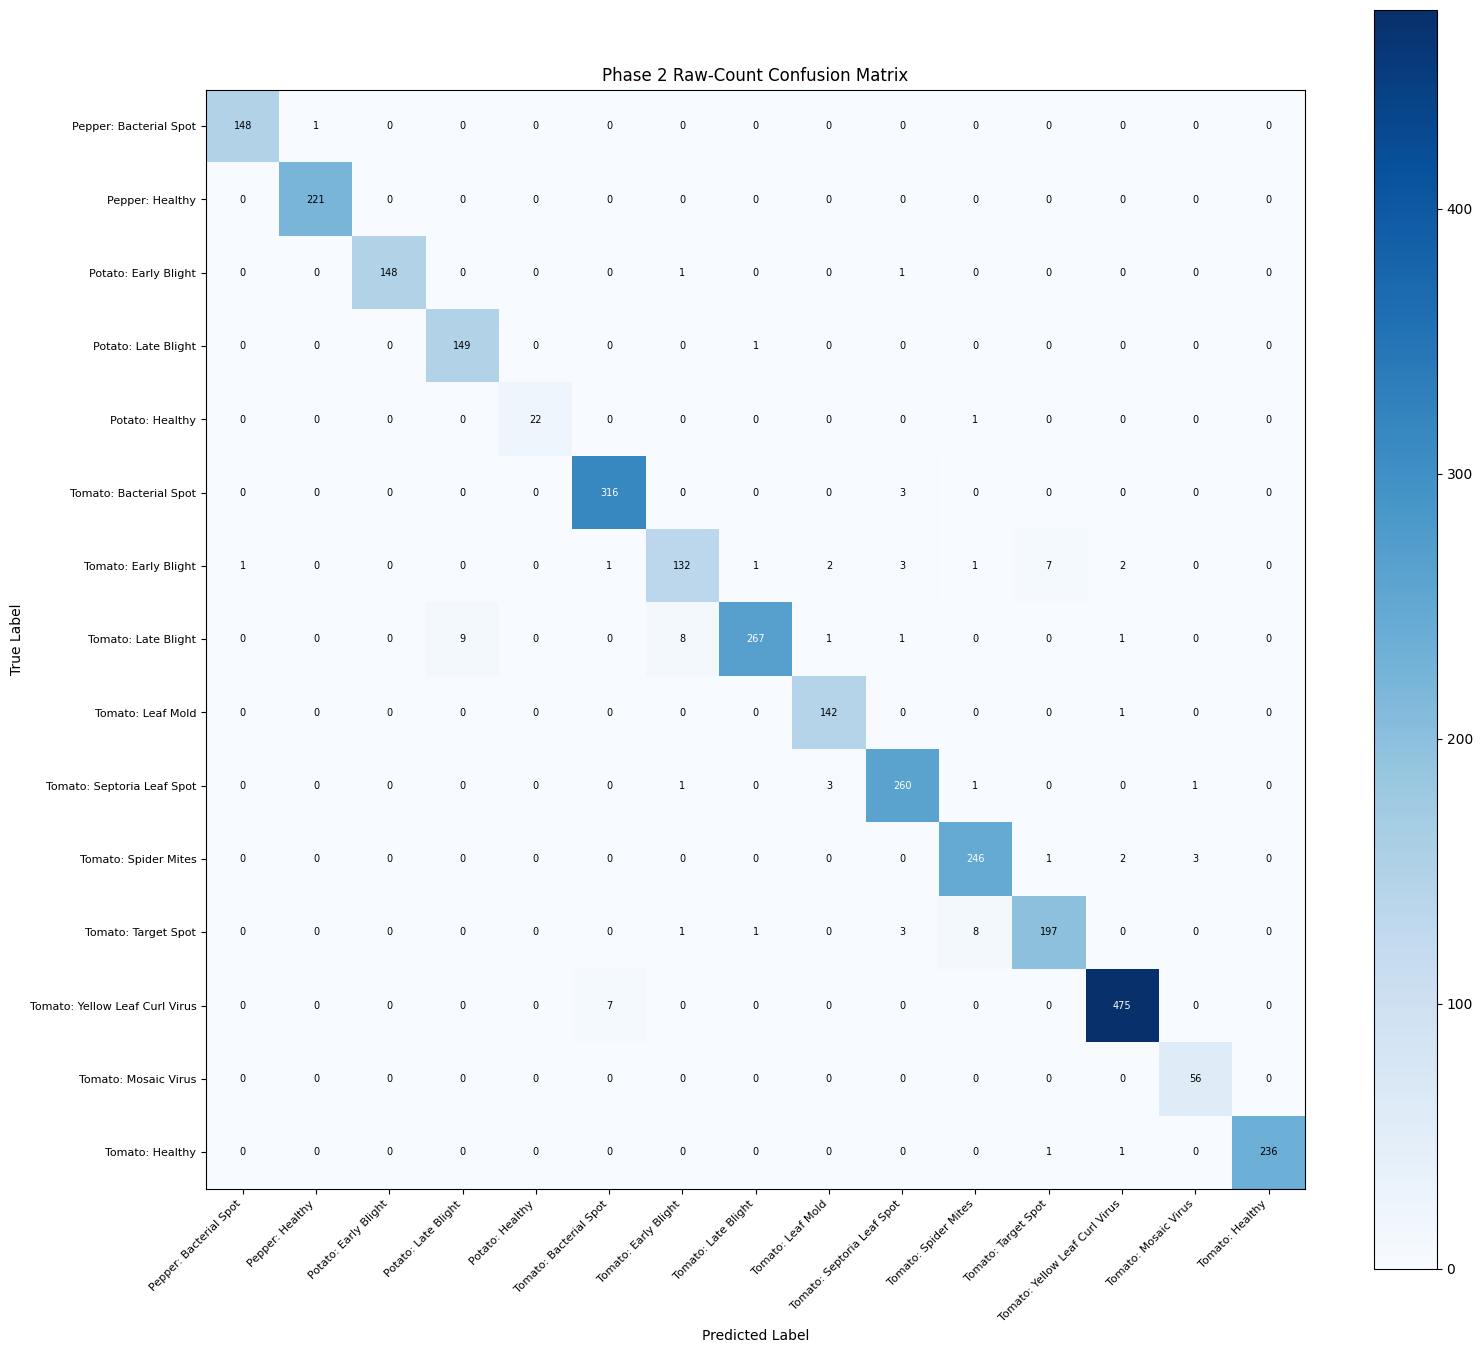

Raw-count Phase 2 confusion matrix saved.


In [30]:
from sklearn.metrics import confusion_matrix

# Recreate Phase 2 predictions for raw-count confusion matrix
y_true_phase2, y_pred_phase2 = [], []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1).cpu().numpy()

        y_pred_phase2.extend(predictions)
        y_true_phase2.extend(labels.numpy())

raw_cm = confusion_matrix(
    y_true_phase2,
    y_pred_phase2,
    labels=list(range(len(info["class_names"]))),
)

fig, ax = plt.subplots(figsize=(16, 14))

image = ax.imshow(raw_cm, cmap="Blues")
fig.colorbar(image, ax=ax)

ax.set_xticks(np.arange(len(DISPLAY_NAMES)))
ax.set_yticks(np.arange(len(DISPLAY_NAMES)))
ax.set_xticklabels(DISPLAY_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(DISPLAY_NAMES, fontsize=8)

for i in range(len(DISPLAY_NAMES)):
    for j in range(len(DISPLAY_NAMES)):
        ax.text(
            j,
            i,
            raw_cm[i, j],
            ha="center",
            va="center",
            fontsize=7,
            color="white" if raw_cm[i, j] > raw_cm.max() * 0.5 else "black",
        )

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Phase 2 Raw-Count Confusion Matrix")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_phase2_raw_counts.png", dpi=300)
plt.show()

print("Raw-count Phase 2 confusion matrix saved.")

In [31]:
final_report_files = [
    RESULTS_DIR / "class_distribution_clean.csv",
    RESULTS_DIR / "class_weights.csv",
    RESULTS_DIR / "classification_report_phase2_display_clean.csv",
    FIGURES_DIR / "class_distribution_clean.png",
    FIGURES_DIR / "sample_images_clean.png",
    FIGURES_DIR / "class_weights.png",
    FIGURES_DIR / "confusion_matrix_phase2_raw_counts.png",
]

for file_path in final_report_files:
    print(file_path.name, "→", file_path.exists())

class_distribution_clean.csv → True
class_weights.csv → True
classification_report_phase2_display_clean.csv → True
class_distribution_clean.png → True
sample_images_clean.png → True
class_weights.png → True
confusion_matrix_phase2_raw_counts.png → True


In [32]:
final_summary = {
    "project_title": "AI-Powered Plant Disease Detection and Classification System",
    "dataset": "PlantVillage",
    "total_images": info["split_sizes"]["total"],
    "number_of_classes": info["n_classes"],
    "train_images": info["split_sizes"]["train"],
    "validation_images": info["split_sizes"]["val"],
    "test_images": info["split_sizes"]["test"],
    "largest_class_count": int(max(info["class_counts"].values())),
    "smallest_class_count": int(min(info["class_counts"].values())),
    "imbalance_ratio": round(max(info["class_counts"].values()) / min(info["class_counts"].values()), 2),
    "phase1_test_accuracy": round(phase1_report["overall_accuracy"], 4),
    "phase1_macro_f1": round(phase1_report["macro avg"]["f1-score"], 4),
    "phase1_weighted_f1": round(phase1_report["weighted avg"]["f1-score"], 4),
    "phase2_test_accuracy": round(phase2_report["overall_accuracy"], 4),
    "phase2_macro_f1": round(phase2_report["macro avg"]["f1-score"], 4),
    "phase2_weighted_f1": round(phase2_report["weighted avg"]["f1-score"], 4),
}

pd.DataFrame([final_summary]).to_csv(
    RESULTS_DIR / "final_project_summary.csv",
    index=False,
)

final_summary

{'project_title': 'AI-Powered Plant Disease Detection and Classification System',
 'dataset': 'PlantVillage',
 'total_images': 20638,
 'number_of_classes': 15,
 'train_images': 14446,
 'validation_images': 3096,
 'test_images': 3096,
 'largest_class_count': 3208,
 'smallest_class_count': 152,
 'imbalance_ratio': 21.11,
 'phase1_test_accuracy': 0.8217,
 'phase1_macro_f1': 0.7914,
 'phase1_weighted_f1': 0.8301,
 'phase2_test_accuracy': 0.9738,
 'phase2_macro_f1': 0.9718,
 'phase2_weighted_f1': 0.9737}

In [33]:
print("Final pipeline completed successfully.")
print("All models, results, figures, and report-ready tables were generated.")
print("Verified final test accuracy:", final_summary["phase2_test_accuracy"])
print("Verified final macro F1:", final_summary["phase2_macro_f1"])
print("Verified final weighted F1:", final_summary["phase2_weighted_f1"])

Final pipeline completed successfully.
All models, results, figures, and report-ready tables were generated.
Verified final test accuracy: 0.9738
Verified final macro F1: 0.9718
Verified final weighted F1: 0.9737
